# Análisis de uso de vehículos eléctricos
## Proyecto Final Data Science II
### Predicción del riesgo de ansiedad por autonomía

**Alumno:** David Alvarez

En este notebook se trabaja con un dataset sintetico de uso de vehiculos electricos en India. El objetivo es probar modelos de Machine Learning para predecir si un viaje puede tener alto riesgo de ansiedad por autonomia (`range_anxiety_risk`).

## Indice

- [Presentacion ejecutiva](#presentacion-ejecutiva)
- [Abstract, motivación y audiencia](#1-abstract-motivación-y-audiencia)
- [Problema de Machine Learning](#2-problema-de-machine-learning)
- [Importación de librerías](#3-importación-de-librerías)
- [Carga del dataset](#4-carga-del-dataset)
- [Primer vistazo a los datos](#5-primer-vistazo-a-los-datos)
- [Limpieza inicial y valores faltantes](#6-limpieza-inicial-y-valores-faltantes)
- [Análisis Exploratorio de Datos — EDA](#7-análisis-exploratorio-de-datos--eda)
- [Ingeniería de atributos](#8-ingeniería-de-atributos)
- [Feature Selection](#feature-selection)
- [Preparación para modelado](#9-preparación-para-modelado)
- [Entrenamiento de modelos base](#10-entrenamiento-de-modelos-base)
- [Optimización de hiperparámetros](#11-optimización-de-hiperparámetros)
- [Evaluación final del mejor modelo](#12-evaluación-final-del-mejor-modelo)
- [Conclusiones finales](#13-conclusiones-finales)

## Presentacion ejecutiva

El objetivo de este proyecto es analizar viajes de vehiculos electricos y predecir si existe riesgo de ansiedad por autonomia. Este problema aparece cuando un usuario puede sentir que no tiene suficiente bateria o autonomia para completar un viaje.

Desde el punto de vista del negocio, detectar estos casos puede ayudar a mejorar la experiencia del usuario, planificar estaciones de carga y entender que factores aumentan el riesgo.

En el trabajo se analizan los datos, se crean nuevas variables, se entrenan modelos de Machine Learning y se elige el modelo con mejor rendimiento.

## 1. Abstract, motivación y audiencia

En este proyecto se analiza un dataset de uso de vehiculos electricos en India. La idea principal es entender que factores pueden estar relacionados con la ansiedad por autonomia, es decir, el miedo o riesgo de que el usuario no tenga suficiente bateria para completar un viaje.

Este analisis puede servirle a empresas de movilidad, operadores de estaciones de carga o areas publicas que quieran mejorar la experiencia de los usuarios y planificar mejor la infraestructura de carga.

## 2. Problema de Machine Learning

La pregunta principal del proyecto es:

> ¿Podemos predecir si un viaje en vehiculo electrico tiene alto riesgo de ansiedad por autonomia?

Este problema se trabaja como una **clasificacion binaria**, donde la variable objetivo es `range_anxiety_risk`:

- `0`: bajo riesgo
- `1`: alto riesgo

## 3. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

plt.style.use('default')

## 4. Carga del dataset

El dataset esta subido a GitHub, asi que se puede cargar directamente desde una URL publica. Esto ayuda a que el notebook se pueda ejecutar en Colab sin depender de una ruta local.

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/rdalvarez/CoderHouse-DataScienceII/refs/heads/main/EV_Usage_Dataset_v2.csv'

df = pd.read_csv(DATA_URL)
df.head()

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,...,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month
0,0f043e7d-c3b7-4478-9566-18494d053204,Mumbai,2026-03-04,2W,3.25,78.31,34.72,2.0,7.0,public_fast,...,9.27,rainy,0.416,low,17.54,1.0,Two-Wheeler,Maharashtra,2026.0,3.0
1,8507eade-6ee7-4c2d-80b1-eacc566a7cb2,Chennai,2026-08-03,4W,37.14,74.38,1.00,3.0,6.0,home,...,7.98,NaN,0.266,low,189.43,1.0,Four-Wheeler,Tamil Nadu,2026.0,8.0
2,cad267b4-0561-490e-9d43-46b0530d9359,Hyderabad,2021-08-10,3W,7.46,94.55,7.74,2.0,3.0,public_slow,...,6.71,rainy,0.092,middle,40.26,0.0,Three-Wheeler,Telangana,2021.0,8.0
3,26e25157-b9fe-41ce-8d40-3fa3c0979de5,Delhi,2023-09-15,2W,2.37,93.46,66.67,3.0,5.0,public_fast,...,8.88,clear,0.251,middle,14.20,1.0,Two-Wheeler,Delhi,2023.0,9.0
4,9ca94273-0df4-48cb-be60-af643dc606f9,Bangalore,2023-09-28,2W,3.16,86.07,NaN,2.0,4.0,home,...,8.93,humid,0.166,low,18.97,0.0,Two-Wheeler,Karnataka,2023.0,9.0


In [3]:
print("Tamaño del dataset:", df.shape)

Tamaño del dataset: (10939, 23)


## 5. Primer vistazo a los datos

In [ ]:
print('Filas y columnas:', df.shape)
df.info()

Filas y columnas: (10939, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10939 entries, 0 to 10938
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       10611 non-null  object 
 1   city                          10611 non-null  object 
 2   trip_date                     10611 non-null  object 
 3   vehicle_type                  10611 non-null  object 
 4   battery_capacity_kwh          10611 non-null  float64
 5   battery_health_pct            10611 non-null  float64
 6   distance_km                   10611 non-null  float64
 7   daily_trip_count              10611 non-null  float64
 8   charging_frequency_per_week   10611 non-null  float64
 9   charging_type                 10611 non-null  object 
 10  charging_duration_min         10611 non-null  float64
 11  charging_station_distance_km  10611 non-null  float64
 12  energy_consumed_kwh           

Se observa que el dataset contiene 10.939 registros y 23 columnas.
También se detectan valores faltantes, ya que la mayoría de las columnas tienen 10.611 valores no nulos.
Por este motivo, en la siguiente sección se realiza una limpieza inicial de los datos.

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10611,10611,318d69a9-3d5f-403c-9c59-0351bb802cb8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10611,7,Pune,1564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_date,10611,2851,2026-10-01,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,10611,3,2W,5329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_capacity_kwh,10611.0,NaN,NaN,NaN,11.964039,14.471872,1.13,2.99,4.27,8.96,55.91
battery_health_pct,10611.0,NaN,NaN,NaN,89.387064,8.560905,62.06,83.005,89.31,95.7,116.95
distance_km,10611.0,NaN,NaN,NaN,26.33739,17.030512,1.0,14.88,25.27,35.72,187.55
daily_trip_count,10611.0,NaN,NaN,NaN,2.518047,0.994011,1.0,2.0,2.0,3.0,6.0
charging_frequency_per_week,10611.0,NaN,NaN,NaN,3.295071,1.474161,1.0,2.0,3.0,4.0,8.0
charging_type,10611,3,public_slow,3606,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A partir de la descripción estadística se observa que la variable objetivo **range_anxiety_risk** tiene una media cercana a 0.24, lo que indica que aproximadamente el 24% de los registros corresponden a viajes con alto riesgo.

Tambien se observan valores atipicos o inconsistentes, como duraciones de carga negativas y porcentajes de salud de bateria superiores al 100%. Estos casos se van a tener en cuenta durante la limpieza y al momento de interpretar los resultados.

## 6. Limpieza inicial y valores faltantes

En esta sección se revisan los valores faltantes del dataset. Primero se intenta eliminar filas completamente vacías y luego se analiza cuántos nulos quedan por columna.

In [5]:
df = df.dropna(how='all').copy()

missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
user_id,328
city,328
trip_date,328
vehicle_type,328
battery_capacity_kwh,328
battery_health_pct,328
distance_km,328
daily_trip_count,328
charging_frequency_per_week,328
charging_type,328


Luego de la limpieza inicial todavia se observan valores faltantes en varias columnas. Como la variable objetivo tambien contiene nulos, se eliminan los registros sin **range_anxiety_risk**, ya que no sirven para entrenar un modelo supervisado.

In [6]:
# Convertimos la fecha para poder crear variables temporales
df['trip_date'] = pd.to_datetime(df['trip_date'], errors='coerce')

# Eliminamos filas sin target porque no sirven para entrenar el modelo
df = df.dropna(subset=['range_anxiety_risk']).copy()
df['range_anxiety_risk'] = df['range_anxiety_risk'].astype(int)

df.shape

(10611, 23)

Luego de eliminar los registros sin variable objetivo, el dataset queda con 10.611 filas y 23 columnas.
A partir de este punto se trabaja solo con registros que pueden ser utilizados para el entrenamiento de modelos supervisados.

## 7. Análisis Exploratorio de Datos — EDA

En esta sección revisamos la distribución del target y algunas variables relevantes para entender el problema antes de modelar.

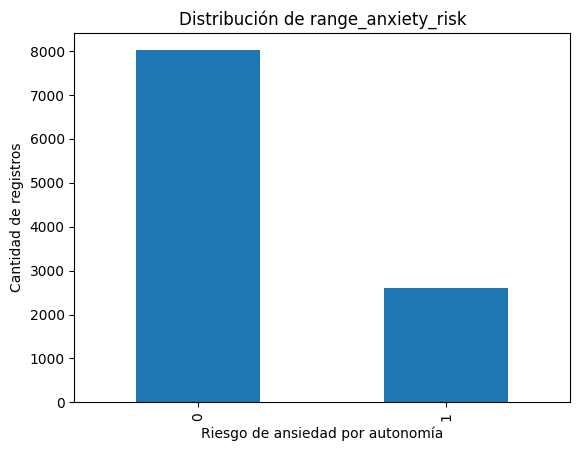

,count
range_anxiety_risk,
0,8017
1,2594


In [7]:
target_counts = df['range_anxiety_risk'].value_counts().sort_index()
target_counts.plot(kind='bar')
plt.title('Distribución de range_anxiety_risk')
plt.xlabel('Riesgo de ansiedad por autonomía')
plt.ylabel('Cantidad de registros')
plt.show()

target_counts

La variable objetivo presenta cierto desbalance: la mayoría de los registros corresponden a viajes de bajo riesgo, mientras que los casos de alto riesgo representan alrededor del 24% del total.

Por este motivo, además de accuracy, será importante evaluar métricas como precision, recall y F1-score, ya que permiten analizar mejor el rendimiento sobre la clase de alto riesgo.

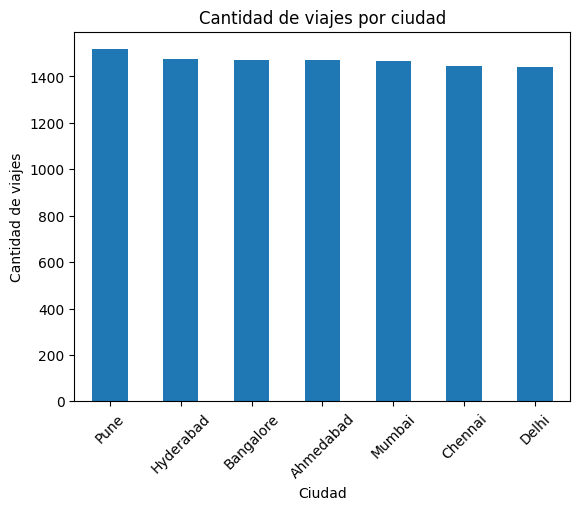

In [8]:
df['city'].value_counts().plot(kind='bar')
plt.title('Cantidad de viajes por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de viajes')
plt.xticks(rotation=45)
plt.show()

La cantidad de viajes por ciudad se encuentra relativamente equilibrada. **Pune** es la ciudad con mayor cantidad de registros, pero la diferencia con el resto de las ciudades no es muy grande.

Esto es positivo para el análisis, ya que el modelo no queda concentrado en una única ciudad.

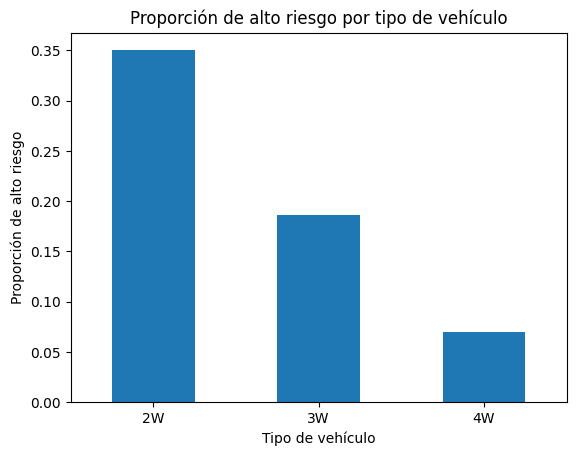

,range_anxiety_risk
vehicle_type,
2W,0.350184
3W,0.186535
4W,0.069444


In [9]:
risk_by_vehicle = df.groupby('vehicle_type')['range_anxiety_risk'].mean().sort_values(ascending=False)

risk_by_vehicle.plot(kind='bar')
plt.title('Proporción de alto riesgo por tipo de vehículo')
plt.xlabel('Tipo de vehículo')
plt.ylabel('Proporción de alto riesgo')
plt.xticks(rotation=0)
plt.show()

risk_by_vehicle

Se observa que el riesgo de ansiedad por autonomía varía según el tipo de vehículo.
Los vehículos de dos ruedas `(2W)` presentan la mayor proporción de alto riesgo, mientras que los vehículos de cuatro ruedas `(4W)` muestran la menor proporción.

Esto puede estar relacionado con diferencias en la capacidad de batería y autonomía estimada de cada tipo de vehículo.

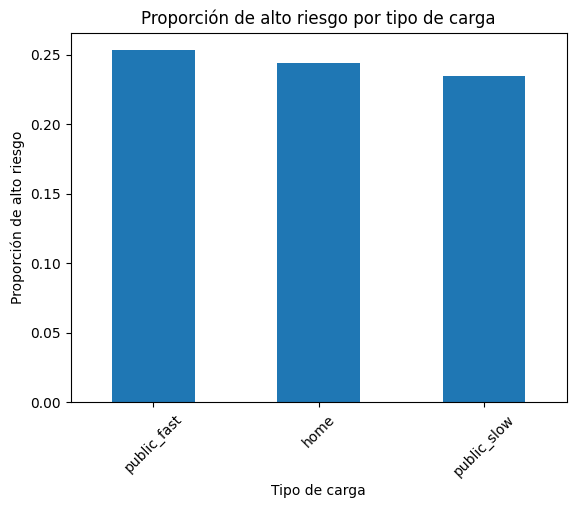

,range_anxiety_risk
charging_type,
public_fast,0.253009
home,0.243765
public_slow,0.234659


In [10]:
risk_by_charging = df.groupby('charging_type')['range_anxiety_risk'].mean().sort_values(ascending=False)

risk_by_charging.plot(kind='bar')
plt.title('Proporción de alto riesgo por tipo de carga')
plt.xlabel('Tipo de carga')
plt.ylabel('Proporción de alto riesgo')
plt.xticks(rotation=45)
plt.show()

risk_by_charging

La proporción de alto riesgo según el tipo de carga es bastante similar entre las categorías.
La carga rápida pública presenta una proporción levemente mayor, aunque la diferencia no parece tan marcada como en el caso del tipo de vehículo.

Esto sugiere que el tipo de vehículo podría tener una relación más fuerte con el riesgo que el tipo de carga.

## 8. Ingeniería de atributos

Creamos algunas variables simples a partir de la fecha y de variables existentes. La idea es sumar información sin hacer el modelo innecesariamente complejo.

In [11]:
df['trip_year'] = df['trip_date'].dt.year
df['trip_month'] = df['trip_date'].dt.month
df['trip_dayofweek'] = df['trip_date'].dt.dayofweek

# Ratio simple para aproximar eficiencia energética del viaje
df['energy_per_km'] = df['energy_consumed_kwh'] / df['distance_km']
df['energy_per_km'] = df['energy_per_km'].replace([np.inf, -np.inf], np.nan)

df[['trip_year', 'trip_month', 'trip_dayofweek', 'energy_per_km']].head()

,trip_year,trip_month,trip_dayofweek,energy_per_km
0,2026.0,3.0,2.0,0.182604
1,2026.0,8.0,0.0,NaN
2,2021.0,8.0,1.0,0.156331
3,2023.0,9.0,4.0,0.236088
4,2023.0,9.0,3.0,NaN


Se crearon variables nuevas a partir de la fecha del viaje y tambien una variable de eficiencia energética (`energy_per_km`), que muestra cuanta energia se consume por kilometro recorrido.

En algunos casos aparecen valores nulos porque las columnas usadas para calcular esta variable ya tenian datos faltantes. Esos casos se van a completar mas adelante dentro del pipeline.

## Feature Selection

Despues de crear nuevas variables, se eligen las columnas que se van a usar para entrenar el modelo.

Se dejan afuera columnas como `user_id`, porque es solo un identificador, `trip_date`, porque ya se transformo en variables de fecha, y columnas repetidas como `vehicle_type_label`, `state`, `year` y `month`.

Las variables finales incluyen informacion del vehiculo, bateria, distancia, carga, clima, trafico, nivel de ingreso y las variables nuevas creadas a partir de la fecha.

## 9. Preparación para modelado

Separamos variables predictoras y variable objetivo. También dejamos fuera identificadores o columnas duplicadas que no aportan directamente al modelo.

In [12]:
target = 'range_anxiety_risk'
columns_to_drop = ['user_id', 'trip_date', 'vehicle_type_label', 'state', 'year', 'month', target]

X = df.drop(columns=columns_to_drop, errors='ignore')
y = df[target]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_features, categorical_features

(['battery_capacity_kwh',
  'battery_health_pct',
  'distance_km',
  'daily_trip_count',
  'charging_frequency_per_week',
  'charging_duration_min',
  'charging_station_distance_km',
  'energy_consumed_kwh',
  'electricity_cost_per_kwh',
  'traffic_density',
  'range_km_estimated',
  'trip_year',
  'trip_month',
  'trip_dayofweek',
  'energy_per_km'],
 ['city',
  'vehicle_type',
  'charging_type',
  'weather_condition',
  'user_income_level'])

Se separaron las variables predictoras de la variable objetivo. Tambien se dejaron afuera columnas que no aportan al modelo o que duplican informacion, como identificadores, fecha original y columnas repetidas.

Las variables numericas van a ser escaladas y las categoricas van a ser transformadas con encoding.

In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Se armo un pipeline de preprocesamiento para no hacer toda la limpieza a mano por separado.
Las variables numericas se completan con la mediana y luego se escalan. Las variables categoricas se completan con el valor mas frecuente y despues se pasan a formato numerico con One Hot Encoding.

Tambien se separaron los datos en entrenamiento y prueba, manteniendo la proporcion de clases con `stratify`.

## 10. Entrenamiento de modelos base

Vamos a entrenar al menos dos modelos: una Regresion Logistica como modelo simple y un Random Forest como modelo de ensamble.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    results.append({'model': name, 'mean_f1_cv': scores.mean(), 'std_f1_cv': scores.std()})

pd.DataFrame(results).sort_values(by='mean_f1_cv', ascending=False)

,model,mean_f1_cv,std_f1_cv
1,Random Forest,0.955689,0.003268
0,Logistic Regression,0.714664,0.017985


En la validacion cruzada, Random Forest obtuvo un F1-score promedio bastante superior al de la Regresion Logistica.
Esto indica que el modelo de ensamble logra capturar mejor las relaciones entre las variables del dataset.

De todos modos, como el dataset es sintetico, los resultados pueden ser mas altos que en un caso real.

## 11. Optimización de hiperparámetros

Optimizamos el modelo Random Forest usando GridSearchCV.

In [16]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_search.best_params_, grid_search.best_score_

({'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 2,
  'model__n_estimators': 200},
 np.float64(0.9580499197226147))

Luego de aplicar GridSearchCV, se elige la combinacion de hiperparametros con mejor F1-score promedio.

El mejor resultado se obtuvo con 200 arboles, sin limite de profundidad, `min_samples_split=2` y `min_samples_leaf=1`.
El F1-score promedio en validacion cruzada fue aproximadamente 0.958.

La busqueda prueba distintas cantidades de arboles, profundidades maximas y criterios de separacion de nodos. Esto permite comparar varias configuraciones y no quedarnos solamente con los parametros por defecto.

## 12. Evaluación final del mejor modelo

In [17]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9712670748940179
Precision: 0.9711934156378601
Recall: 0.9094412331406551
F1: 0.9393034825870646
ROC-AUC: 0.9905612894545909

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1604
           1       0.97      0.91      0.94       519

    accuracy                           0.97      2123
   macro avg       0.97      0.95      0.96      2123
weighted avg       0.97      0.97      0.97      2123



El modelo final obtiene muy buenos resultados sobre el conjunto de prueba.
Para la clase de alto riesgo, el F1-score es 0.94, lo que indica que el modelo detecta correctamente gran parte de los casos positivos.

Tambien se observa un ROC-AUC muy alto, cercano a 0.99. Esto muestra que el modelo logra separar bastante bien los viajes de bajo y alto riesgo.

De todos modos, como el dataset es sintetico, estos resultados pueden ser mas altos que los que saldrian usando datos reales.

In [18]:
confusion_matrix(y_test, y_pred)

array([[1590,   14],
       [  47,  472]])

La matriz de confusion muestra que el modelo clasifica correctamente la mayoria de los casos.
Detecta correctamente 472 viajes de alto riesgo y se equivoca en 47 casos, donde predice bajo riesgo cuando en realidad eran viajes de alto riesgo.

En este problema, esos falsos negativos son importantes, porque podrian representar usuarios con riesgo de quedarse sin autonomia que no fueron detectados por el modelo.

## 13. Conclusiones finales

En este proyecto se trabajo con un dataset de uso de vehiculos electricos en India, con el objetivo de predecir si un viaje podia presentar alto riesgo de ansiedad por autonomia.

Primero se realizo una exploracion inicial de los datos, donde se detectaron valores faltantes y algunas inconsistencias, como duraciones de carga negativas o porcentajes de salud de bateria superiores al 100%. Tambien se observo que la variable objetivo estaba algo desbalanceada, ya que los casos de alto riesgo representaban aproximadamente el 24% del total.

Durante el EDA se vio que el tipo de vehiculo tiene una relacion importante con el riesgo. Los vehiculos de dos ruedas presentaron una mayor proporcion de alto riesgo, mientras que los de cuatro ruedas tuvieron una proporcion menor. Esto puede estar relacionado con diferencias en capacidad de bateria y autonomia estimada.

Para el modelado se entrenaron dos modelos: Regresion Logistica y Random Forest. Random Forest obtuvo mejores resultados en la validacion cruzada, por lo que luego se optimizo con GridSearchCV.

El modelo final obtuvo muy buen rendimiento en el conjunto de prueba, con un F1-score cercano a 0.94 para la clase de alto riesgo y un ROC-AUC cercano a 0.99. Esto indica que el modelo logra separar bastante bien los viajes de bajo y alto riesgo.

De todas formas, es importante aclarar que el dataset es sintetico, por lo que los resultados pueden salir mejores que en un caso con datos reales. Como proximo paso, estaria bueno probar este mismo enfoque con informacion real de usuarios y estaciones de carga, y tambien mirar con mas detalle los falsos negativos, que son los casos donde el modelo no detecta un viaje que realmente era de alto riesgo.